## Workflow



| Steps   |      description     |  metric |
|----------|:-------------:|------:|
| Order received | Day 1 |  Number of Orders, percentage of correct filled orders   |
| Order processing and shipping phase |    normally 2 Days, limited visibility   |   percentage of right processing, preparation/processing time, packaging time,  total shipping time |
| order shipped | delivered by external truck comapny on following day if possible, limited visibility |  delivery time  |
|delivered | customer received order, average 3 days time, unclear if thats true due to qr scan | total order time
    


------------------------------------------------------------
- claim:  complete data on the **Order Date** and the On **Truck Scan Date** --> check if its true.  

- but:  limited visibility of what happens in between or after --> when the truck leaves its unknown how much time it takes. 

- they have sent into the warehouse to record the **Ready to Ship Date** for as many orders as possible -> missing values

Dates ordered

1. Order Date from Orders

2. Order Date from Order Process Data - from the warehouse, is it the same as from orders? Customers can send orders every day, but the WH only operates from Mon. to Fri.. Orders received on weekends are processed on Monday.

3. Ready to Ship Date from InternStudy Data - ready to ship at warehouse

4. On Truck Scan Date from Order Process Date - order picked up by logisticks company?

4. Pickup Date from InternStudy Data - actual pick up from warehouse, does this match day reported from logistics company?

5. Arrival Scan Date from Campaing Data - the day customer scans and claims order arrived, not regular only done through promotion


# Hypotheses
1. **Limited visibility**: The company has limited data on the shipping and delivery stages, making it difficult to accurately assess the full delivery process. -  Ilayda in progress, in the main file
2. **Warehouse processing time**: Orders are expected to be ready for shipping within 2 days, but the actual processing time may be longer on average. - Mang done
4. **Express orders**: Express orders are processed and shipped significantly faster than standard orders. - Mang done,
5. Warehouse processing takes around two working days - same as 2, done
6. Weekend orders take longer to process than weekday orders. - Mang finsihed it
7. Express orders are processed and shipped faster than Standard orders. - same as 4, open
8. Orders ready on Friday experience longer waiting times because trucks leave only on Monday, Wednesday, and Friday. - delivery time by day of the order -> if Monday, but then, focus on weekdays Fruzsi
9. Some orders miss the next available truck. -open difference between ready for ship and pick up time, from Internstudy, Lauritz already calulated it
10.Transportation takes approximately three days after shipment. - Lauritz in progress 
11. Most variation in delivery time comes from warehouse processing or waiting for a truck. - assigned Mang
12. Daily pickups would reduce total delivery time. -Ilayda in progress
13. Processing all orders as Express would improve delivery performance.

In [451]:
import pandas as pd
import matplotlib.pyplot as plt

***First Dataset***

In [452]:
orders_raw = pd.read_excel('./Muesli Project raw data.xlsx', sheet_name='Orders', header = 1)
orders_raw.head(3) 

,Index,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Origin Channel,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Product ID,Sales,Quantity,Discount,Profit
0,27,CA-2019-121755,2019-01-16,Second Class,EH-13945,Eric Hoffmann,Email,United States,Los Angeles,California,90049.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10003027,90.57,3,0.0,11.7741
1,45,CA-2019-118255,2019-03-11,First Class,ON-18715,Odella Nelson,Sales,United States,Eagan,Minnesota,55122.0,Central,Special Projects Muesil,Gluten Free,TEC-AC-10000171,45.98,2,0.0,19.7714
2,48,CA-2019-169194,2019-06-20,Standard Class,LH-16900,Lena Hernandez,Email,United States,Dover,Delaware,19901.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,45.00,3,0.0,4.9500


In [453]:
orders_raw.info() #gives us the shape of the dataset, the dtypes, null counts and column names

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Index           9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Mode       9994 non-null   str           
 4   Customer ID     9994 non-null   str           
 5   Customer Name   9994 non-null   str           
 6   Origin Channel  9994 non-null   str           
 7   Country/Region  9994 non-null   str           
 8   City            9994 non-null   str           
 9   State           9994 non-null   str           
 10  Postal Code     9983 non-null   float64       
 11  Region          9994 non-null   str           
 12  Category        9994 non-null   str           
 13  Sub-Category    9994 non-null   str           
 14  Product ID      9994 non-null   str           
 15  Sales          

**Cleaning the first Data Set**

In [454]:
orders_raw.isnull().sum() #eleven postal codes are missing

Index              0
Order ID           0
Order Date         0
Ship Mode          0
Customer ID        0
Customer Name      0
Origin Channel     0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Category           0
Sub-Category       0
Product ID         0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [455]:
#cleaning the column names

orders_raw.columns = (orders_raw.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_').str.replace('-', '_'))

In [456]:
#To indentify the missing records
orders_raw[orders_raw['postal_code'].isna()]
#the postal code for state vermont in the city burlington is missing for the region east

,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit
173,2235,CA-2020-104066,2020-12-05,Standard Class,QJ-19255,Quincy Jones,Sales,United States,Burlington,Vermont,NaN,East,Special Projects Muesil,Gluten Free,TEC-AC-10001013,205.03,7,0.0,67.6599
710,9147,US-2019-165505,2019-01-23,Standard Class,CB-12535,Claudia Bergmann,Sales,United States,Burlington,Vermont,NaN,East,Special Projects Muesil,Gluten Free,TEC-AC-10002926,99.98,2,0.0,42.9914
1732,9389,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Mega Protein,OFF-AP-10000828,542.94,3,0.0,152.0232
3408,9387,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Nuts and more,OFF-PA-10000157,79.92,4,0.0,37.5624
3409,9388,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Nuts and more,OFF-PA-10001970,12.28,1,0.0,5.7716
4279,8799,US-2019-150140,2019-04-06,Standard Class,VM-21685,Valerie Mitchum,Facebook,United States,Burlington,Vermont,NaN,East,Special Projects Muesil,Only Oats,TEC-PH-10002555,1294.75,5,0.0,336.6350
4694,9390,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Power Clean Fibre Boost,OFF-EN-10001509,2.04,1,0.0,0.9588
5490,9149,US-2019-165505,2019-01-23,Standard Class,CB-12535,Claudia Bergmann,Sales,United States,Burlington,Vermont,NaN,East,Power Muesli,Steel Cut,OFF-ST-10001526,1564.29,13,0.0,406.7154
7802,9148,US-2019-165505,2019-01-23,Standard Class,CB-12535,Claudia Bergmann,Sales,United States,Burlington,Vermont,NaN,East,Power Muesli,Super Mega Protein,OFF-AR-10003477,8.04,6,0.0,2.7336
8415,9742,CA-2018-117086,2018-11-08,Standard Class,QJ-19255,Quincy Jones,Sales,United States,Burlington,Vermont,NaN,East,Toasted Muesli,With Fruit,FUR-BO-10004834,4404.90,5,0.0,1013.1270


In [457]:
#To check the postal codes that do exist for Burlington, Vermont in the dataset. !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
orders_raw[
    (orders_raw['city'] == 'Burlington') &
    (orders_raw['state'] == 'Vermont')]['postal_code'].value_counts(dropna=False)

postal_code
NaN    11
Name: count, dtype: int64

In [458]:
#filling the postal code with 05401 and changing into a string
orders_raw['postal_code'] = orders_raw['postal_code'].astype('string')

orders_raw.loc[
    orders_raw['postal_code'].isna(),
    'postal_code'
] = '05401'

In [459]:
#checking if it worked and it did :)
orders_raw.isnull().sum() 

index             0
order_id          0
order_date        0
ship_mode         0
customer_id       0
customer_name     0
origin_channel    0
country_region    0
city              0
state             0
postal_code       0
region            0
category          0
sub_category      0
product_id        0
sales             0
quantity          0
discount          0
profit            0
dtype: int64

In [460]:
#checking for duplicates and there are no duplicates
orders_raw.duplicated().sum()

np.int64(0)

In [461]:
#To fix the data types

orders_raw['order_date'] = pd.to_datetime(orders_raw['order_date'])

orders_raw['sales'] = pd.to_numeric(orders_raw['sales'])
orders_raw['quantity'] = pd.to_numeric(orders_raw['quantity'])
orders_raw['discount'] = pd.to_numeric(orders_raw['discount'])
orders_raw['profit'] = pd.to_numeric(orders_raw['profit'])

orders_raw.dtypes

index                      int64
order_id                     str
order_date        datetime64[us]
ship_mode                    str
customer_id                  str
customer_name                str
origin_channel               str
country_region               str
city                         str
state                        str
postal_code               string
region                       str
category                     str
sub_category                 str
product_id                   str
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
dtype: object

**Analysing the first Dataset**

In [462]:
#checking the values for the columns:ship mode, region, category
print("ship_mode:")
display(orders_raw['ship_mode'].value_counts())

print("origin_channel:")
display(orders_raw['origin_channel'].value_counts())

print("region:")
display(orders_raw['region'].value_counts())

print("category:")
display(orders_raw['category'].value_counts())



ship_mode:


ship_mode
Standard Class    5968
First Class       2081
Second Class      1945
Name: count, dtype: int64

origin_channel:


origin_channel
Email       5191
Sales       3020
Facebook    1783
Name: count, dtype: int64

region:


region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

category:


category
Power Muesli               6026
Toasted Muesli             2121
Special Projects Muesil    1847
Name: count, dtype: int64

In [463]:

orders_raw[['sales', 'quantity', 'discount', 'profit']].describe()

,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [464]:
print("Unique Order IDs:")
display(orders_raw['order_id'].nunique())

print("Unique Customer IDs:")
display(orders_raw['customer_id'].nunique())

print("Unique Product IDs:")
display(orders_raw['product_id'].nunique())

Unique Order IDs:


5009

Unique Customer IDs:


793

Unique Product IDs:


1862

In [465]:
#checking numerical range and outlier
orders_raw[['sales', 'quantity', 'discount', 'profit']].describe()

,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [466]:
Q1 = orders_raw['sales'].quantile(0.25)
Q3 = orders_raw['sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Sales lower bound:", lower)
print("Sales upper bound:", upper)

Sales lower bound: -271.71000000000004
Sales upper bound: 498.93


In [467]:
# Check for suspicious values

print("Sales < 0:")
display(orders_raw[orders_raw['sales'] < 0]) #no result

print("Quantity <= 0:")
display(orders_raw[orders_raw['quantity'] <= 0]) #no result

print("Discount < 0:")
display(orders_raw[orders_raw['discount'] < 0])#no result

print("Discount > 1:")
display(orders_raw[orders_raw['discount'] > 1]) #no result

print("Profit < 0:")
display(orders_raw[orders_raw['profit'] < 0])

Sales < 0:


,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


Quantity <= 0:


,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


Discount < 0:


,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


Discount > 1:


,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


Profit < 0:


,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit
6,101,CA-2019-158568,2019-08-29,Standard Class,RB-19465,Rick Bensley,Facebook,United States,Chicago,Illinois,60610.0,Central,Special Projects Muesil,Gluten Free,TEC-AC-10001767,95.976,3,0.2,-10.7973
7,104,US-2018-156867,2018-11-13,Standard Class,LC-16870,Lena Cacioppo,Email,United States,Aurora,Colorado,80013.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10001552,238.896,6,0.2,-26.8758
16,236,US-2020-100930,2020-04-07,Standard Class,CS-12400,Christopher Schild,Facebook,United States,Tampa,Florida,33614.0,South,Special Projects Muesil,Gluten Free,TEC-AC-10003832,617.976,3,0.2,-7.7247
27,376,US-2017-119137,2017-07-23,Standard Class,AG-10900,Arthur Gainer,Email,United States,Tucson,Arizona,85705.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10002076,479.040,10,0.2,-29.9400
29,386,US-2018-168935,2018-11-27,Standard Class,DO-13435,Denny Ordway,Email,United States,Pembroke Pines,Florida,33024.0,South,Special Projects Muesil,Gluten Free,TEC-AC-10002335,83.976,3,0.2,-1.0497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9982,9791,CA-2020-144491,2020-03-27,Standard Class,CJ-12010,Caroline Jumper,Email,United States,Houston,Texas,77070.0,Central,Toasted Muesli,With Nuts,FUR-CH-10001714,211.246,2,0.3,-66.3916
9983,9793,CA-2017-127166,2017-05-21,Second Class,KH-16360,Katherine Hughes,Email,United States,Houston,Texas,77070.0,Central,Toasted Muesli,With Nuts,FUR-CH-10003396,107.772,2,0.3,-29.2524
9985,9827,US-2017-164406,2017-08-15,Standard Class,BD-11605,Brian Dahlen,Email,United States,San Francisco,California,94122.0,West,Toasted Muesli,With Nuts,FUR-CH-10003833,195.136,4,0.2,-12.1960
9991,9913,CA-2018-132388,2018-10-10,First Class,KN-16390,Katherine Nockton,Sales,United States,Santa Barbara,California,93101.0,West,Toasted Muesli,With Nuts,FUR-CH-10001714,362.136,3,0.2,-54.3204


In [468]:
# Check whether identifiers behave as expected

print("Unique Order IDs:")
display(orders_raw['order_id'].nunique())

print("Unique Customer IDs:")
display(orders_raw['customer_id'].nunique())

print("Unique Product IDs:")
display(orders_raw['product_id'].nunique())

#The dataset contains 5,009 orders made by 793 customers, involving 1,862 different products.
#5,009 orders vs. 793 customers → customers place multiple orders on average.
#1,862 products vs. 5,009 orders → many orders likely contain products that also appear in other orders.
#One order can consist of multiple order lines/products, meaning the same order_id can appear multiple times.

Unique Order IDs:


5009

Unique Customer IDs:


793

Unique Product IDs:


1862

In [469]:
#to check repeated orders

orders_raw['order_id'].value_counts().head(10) #shows that same customers ordered several times

order_id
CA-2020-100111    14
CA-2020-157987    12
CA-2019-165330    11
US-2019-108504    11
CA-2018-131338    10
US-2018-126977    10
CA-2019-105732    10
CA-2020-117457     9
CA-2017-106439     9
CA-2020-140949     9
Name: count, dtype: int64

In [470]:
#To check whether the customer has multiple orders                      

orders_raw.groupby('customer_id')['order_id'].nunique().describe()
# 6.3 orders per customer; someone ordered 17 times

count    793.000000
mean       6.316520
std        2.550885
min        1.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       17.000000
Name: order_id, dtype: float64

***Second Dataset***

In [471]:
campaign_raw = pd.read_excel('./Muesli Project raw data.xlsx', sheet_name='Campaign Data')
campaign_raw.head()

,Order ID,Arrival Scan Date,Customer Name
0,CA-2019-109666,2019-05-03,Kunst Miller
1,CA-2019-138933,2019-05-03,Jack Lebron
2,CA-2019-130001,2019-05-03,Heather Kirkland
3,CA-2019-113061,2019-05-06,Ed Ludwig
4,CA-2019-162138,2019-05-06,Grace Kelly


In [472]:
# Your code here — .info(), .describe()             
campaign_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           333 non-null    str           
 1   Arrival Scan Date  333 non-null    datetime64[us]
 2   Customer Name      333 non-null    str           
dtypes: datetime64[us](1), str(2)
memory usage: 7.9 KB


**Cleaning the Second Dataset**

In [473]:
#cleaning the column names

campaign_raw.columns = (campaign_raw.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_').str.replace('-', '_'))

In [474]:
campaign_raw.isnull().sum() #no missing values

order_id             0
arrival_scan_date    0
customer_name        0
dtype: int64

In [475]:
campaign_raw.duplicated().sum() #no duplicates either

np.int64(0)

**Analysing the Second Dataset**

In [476]:
campaign_raw.describe()

#the company said data over past few years, its only 1 year

,arrival_scan_date
count,333
mean,2019-10-14 19:36:12.972973
min,2019-05-03 00:00:00
25%,2019-09-09 00:00:00
50%,2019-10-21 00:00:00
75%,2019-12-16 00:00:00
max,2020-05-15 00:00:00


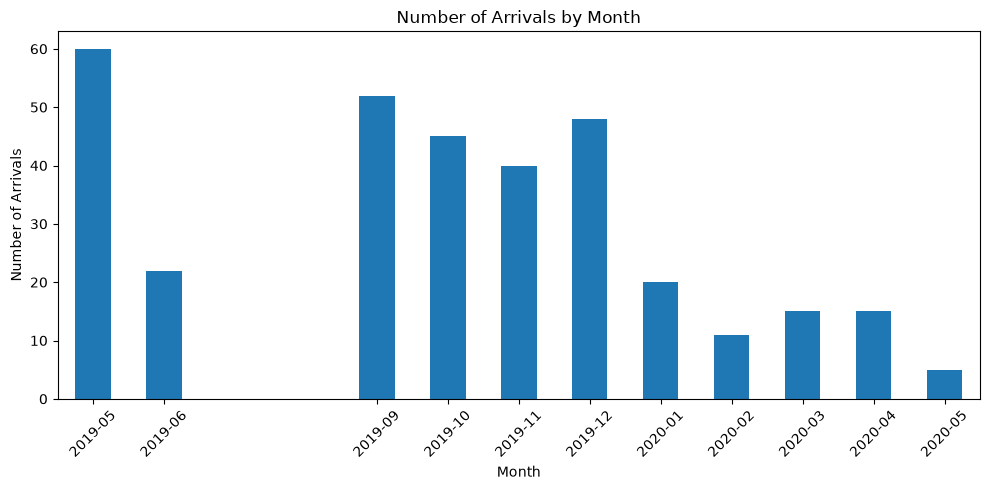

In [477]:
# Count the number of arrivals for each month
monthly_arrivals = (campaign_raw.groupby(campaign_raw['arrival_scan_date'].dt.to_period('M')) .size())

# Create a bar chart to visualize monthly arrivals
monthly_arrivals.plot(kind='bar',figsize=(10, 5))

plt.title('Number of Arrivals by Month')
plt.xlabel('Month')
plt.ylabel('Number of Arrivals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#there is a pause from july to september 2019

***Third Dataset***

In [478]:
order_process_raw = pd.read_excel('./Muesli Project raw data.xlsx', sheet_name='Order Process Data')
order_process_raw.head()

,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing


In [479]:
#shows shape, null count, dtypes, column names
order_process_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5899 entries, 0 to 5898
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Row ID              5899 non-null   int64         
 1   Order ID            5899 non-null   str           
 2   Order Date          5899 non-null   datetime64[us]
 3   On Truck Scan Date  5899 non-null   datetime64[us]
 4   Ship Mode           5899 non-null   str           
dtypes: datetime64[us](2), int64(1), str(2)
memory usage: 230.6 KB


**Cleaning the Third Dataset**

In [480]:
order_process_raw.isnull().sum()
#no missing data

Row ID                0
Order ID              0
Order Date            0
On Truck Scan Date    0
Ship Mode             0
dtype: int64

In [481]:
order_process_raw.duplicated().sum()
#no duplicates

np.int64(0)

In [482]:
# cleaning the column names
order_process_raw.columns = ( order_process_raw.columns.str.strip().str.lower() .str.replace(' ', '_').str.replace('/', '_') .str.replace('-', '_'))

In [483]:
# Convert the order date and truck scan date columns to datetime format.
# This allows us to work with the dates correctly, for example
# when calculating delivery times or analyzing orders over time.

order_process_raw['order_date'] = pd.to_datetime(order_process_raw['order_date'])
order_process_raw['on_truck_scan_date'] = pd.to_datetime(order_process_raw['on_truck_scan_date'])

**Analysing the Third Dataset**

In [484]:
#To check the date range to make sure whether the date make sense
print("Order date:")
print(order_process_raw['order_date'].min())
print(order_process_raw['order_date'].max())

print("\nTruck scan date:")
print(order_process_raw['on_truck_scan_date'].min())
print(order_process_raw['on_truck_scan_date'].max())


Order date:
2019-01-02 00:00:00
2020-12-30 00:00:00

Truck scan date:
2019-01-07 00:00:00
2021-01-06 00:00:00


In [485]:
# To check for invalid dates to make sure no order was scanned before it was ordered.
invalid_dates = order_process_raw[
    order_process_raw['on_truck_scan_date'] < order_process_raw['order_date']  ]

len(invalid_dates)

0

In [486]:
#To calculate warehouse processing time
order_process_raw['processing_days'] = ( order_process_raw['on_truck_scan_date'] -order_process_raw['order_date']).dt.days
order_process_raw[['order_date', 'on_truck_scan_date', 'processing_days']].head()

,order_date,on_truck_scan_date,processing_days
0,2019-01-03,2019-01-07,4
1,2019-01-02,2019-01-09,7
2,2019-01-02,2019-01-09,7
3,2019-01-03,2019-01-09,6
4,2019-01-03,2019-01-09,6


In [487]:
order_process_raw['processing_days'].describe() 

count    5899.000000
mean        6.120529
std         2.509031
min         0.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        12.000000
Name: processing_days, dtype: float64

## Hypothese 2
 **Warehouse processing time**: Orders are expected to be ready for shipping within 2 days, but the actual processing time may be longer on average.
- Average processing time = 6.12 days.
- Median processing time = 7 days. based on the current data, the warehouse is not normally processing orders within 2 days.

In [488]:
#To check 2 days target
order_process_raw['within_2_days'] = (order_process_raw['processing_days'] <= 2)
order_process_raw['within_2_days'].value_counts()

within_2_days
False    5277
True      622
Name: count, dtype: int64

In [489]:
order_process_raw['within_2_days'].mean() * 100
# This means 10.54% of your orders were processed within 2 days.

np.float64(10.54416002712324)

In [490]:
# How many orders miss the target?
orders_over_2_days = (order_process_raw['processing_days'] > 2).sum()

orders_over_2_days

np.int64(5277)

In [491]:
orders_over_2_days / len(order_process_raw) * 100

np.float64(89.45583997287676)

In [492]:
# To analyze processing time by Ship Mode, because different shipping methods may have different warehouse processing patterns.
order_process_raw.groupby('ship_mode')['processing_days'].describe()

,count,mean,std,min,25%,50%,75%,max
ship_mode,,,,,,,,
Express,1303.0,2.568688,1.638534,0.0,1.0,3.0,4.0,6.0
Standard Processing,4596.0,7.127502,1.651674,2.0,6.0,7.0,8.0,12.0


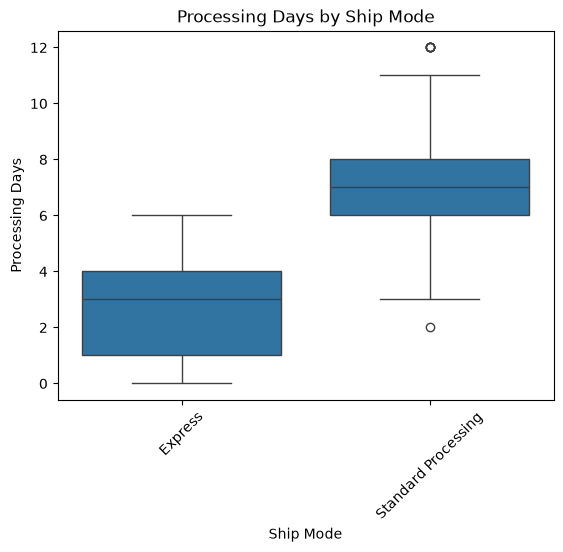

In [493]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize processing days by shipping mode
sns.boxplot(
    data=order_process_raw,
    x='ship_mode',
    y='processing_days'
)

plt.title('Processing Days by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Processing Days')
plt.xticks(rotation=45)
plt.show()

In [494]:
order_process_raw.groupby('ship_mode')['within_2_days'].mean() * 100

# Express: about 47.66% of orders met the 2-day target. Standard Processing: only about 0.02% met the 2-day target.

ship_mode
Express                47.659248
Standard Processing     0.021758
Name: within_2_days, dtype: float64

In [495]:
#To identify extreme delays
Q1 = order_process_raw['processing_days'].quantile(0.25)
Q3 = order_process_raw['processing_days'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 5.0
Q3: 8.0
IQR: 3.0
Lower bound: 0.5
Upper bound: 12.5


In [496]:
outliers = order_process_raw[(order_process_raw['processing_days'] < lower_bound) |(order_process_raw['processing_days'] > upper_bound)]
outliers
#152 rows, so there are 152 outliers

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,processing_days,within_2_days
179,1705,CA-2019-106306,2019-03-08,2019-03-08,Express,0,True
181,9698,CA-2019-122511,2019-03-11,2019-03-11,Express,0,True
282,7695,CA-2019-118899,2019-03-22,2019-03-22,Express,0,True
291,3371,CA-2019-134887,2019-03-25,2019-03-25,Express,0,True
317,8572,CA-2019-162222,2019-04-03,2019-04-03,Express,0,True
...,...,...,...,...,...,...,...
5594,6716,CA-2020-107629,2020-12-14,2020-12-14,Express,0,True
5687,4104,CA-2020-137456,2020-12-21,2020-12-21,Express,0,True
5698,883,US-2020-123463,2020-12-23,2020-12-23,Express,0,True
5746,4620,CA-2020-145219,2020-12-24,2020-12-24,Express,0,True


In [497]:
# to inspect the outlier

outliers[['order_id', 'order_date',  'on_truck_scan_date', 'ship_mode', 'processing_days']].sort_values('processing_days', ascending=False)

,order_id,order_date,on_truck_scan_date,ship_mode,processing_days
179,CA-2019-106306,2019-03-08,2019-03-08,Express,0
4021,US-2020-118941,2020-08-12,2020-08-12,Express,0
3748,CA-2020-168109,2020-07-03,2020-07-03,Express,0
3749,CA-2020-168109,2020-07-03,2020-07-03,Express,0
3768,US-2020-152492,2020-07-06,2020-07-06,Express,0
...,...,...,...,...,...
2275,US-2019-148803,2019-12-11,2019-12-11,Express,0
2276,CA-2019-162187,2019-12-11,2019-12-11,Express,0
2277,CA-2019-162187,2019-12-11,2019-12-11,Express,0
2278,CA-2019-162187,2019-12-11,2019-12-11,Express,0


## Hypothese 4
**Express orders**: Express orders are processed and shipped significantly faster than standard orders. 

- Express: about 47.66% of orders met the 2-day target. Standard Processing: only about 0.02% met the 2-day target.

In [498]:
#To analyze the distribution
order_process_raw['processing_days'].value_counts().sort_index()


processing_days
0      152
1      248
2      222
3      373
4      435
5      602
6      765
7     1165
8     1022
9      565
10     318
11      26
12       6
Name: count, dtype: int64

In [499]:
#To show inn percentage
order_process_raw['processing_days'].value_counts(
    normalize=True
).sort_index() * 100

processing_days
0      2.576708
1      4.204102
2      3.763350
3      6.323106
4      7.374131
5     10.205120
6     12.968300
7     19.749110
8     17.324970
9      9.577895
10     5.390744
11     0.440753
12     0.101712
Name: proportion, dtype: float64

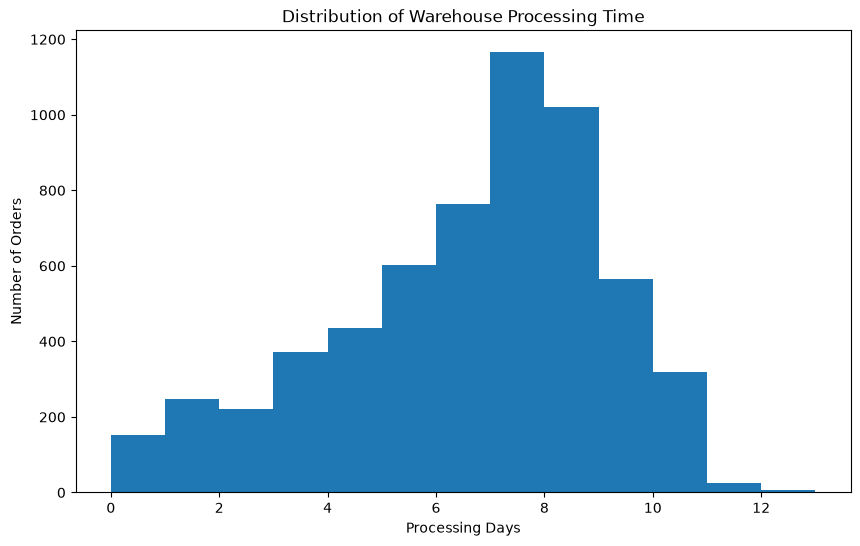

In [500]:
# To create visualization

plt.figure(figsize=(10, 6))
plt.hist(order_process_raw['processing_days'], bins=range(
    order_process_raw['processing_days'].min(),
    order_process_raw['processing_days'].max() + 2
))
plt.xlabel('Processing Days')
plt.ylabel('Number of Orders')
plt.title('Distribution of Warehouse Processing Time')
plt.show()

***Fourth Dataset***

In [501]:
intern_data_study = pd.read_excel('./Muesli Project raw data.xlsx', sheet_name='InternData Study')
intern_data_study.head()

,Order ID,Ready to Ship Date,Pickup Date
0,CA-2019-116540,2019-09-02,2019-09-03
1,CA-2019-116540,2019-09-02,2019-09-03
2,CA-2019-129847,2019-09-04,2019-09-04
3,CA-2019-129630,2019-09-04,2019-09-04
4,CA-2019-106278,2019-09-05,2019-09-06


In [502]:
#check the shape, columns, dtypes and nullcounts
intern_data_study.info()

# ready to ship and Pickup Date are datetime and Ordr Id is object

<class 'pandas.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Order ID            290 non-null    str           
 1   Ready to Ship Date  290 non-null    datetime64[us]
 2   Pickup Date         290 non-null    datetime64[us]
dtypes: datetime64[us](2), str(1)
memory usage: 6.9 KB


**Cleaning the Fourth Dataset**

In [503]:
# there are 86 duplicated rows in the dataset
# delete duplicates
intern_data_study.duplicated().sum()

np.int64(86)

In [504]:
# there are 86 duplicated rows in Order ID
intern_data_study['Order ID'].duplicated().sum()

np.int64(86)

In [505]:
# latest Pickup date in the dataset
max_date_pickup = intern_data_study['Pickup Date'].max()
max_date_pickup

Timestamp('2020-12-09 00:00:00')

In [506]:
# earliest Pickup date in the dataset
min_date_pickup = intern_data_study['Pickup Date'].min()
min_date_pickup

Timestamp('2019-09-03 00:00:00')

In [507]:
# 463 days timespan
time_differnce = max_date_pickup - min_date_pickup
time_differnce

Timedelta('463 days 00:00:00')

**Analysing the Fourth Dataset**

In [508]:
intern_data_study.describe()

,Ready to Ship Date,Pickup Date
count,290,290
mean,2020-06-18 15:08:41.379310,2020-06-20 06:47:10.344827
min,2019-09-02 00:00:00,2019-09-03 00:00:00
25%,2019-09-23 00:00:00,2019-09-23 12:00:00
50%,2020-11-10 00:00:00,2020-11-12 00:00:00
75%,2020-11-23 00:00:00,2020-11-23 00:00:00
max,2020-12-07 00:00:00,2020-12-09 00:00:00


In [509]:
# calculate delivery time in days between ready to ship and pickup; make it more accurate and use hours?

intern_data_study['storagetime'] = intern_data_study['Pickup Date'] - intern_data_study['Ready to Ship Date']
intern_data_study['storagetime']

0     1 days
1     1 days
2     0 days
3     0 days
4     1 days
       ...  
285   3 days
286   3 days
287   3 days
288   3 days
289   2 days
Name: storagetime, Length: 290, dtype: timedelta64[us]

In [510]:
# create updated dataset with delivery time column
intern_data_study.to_excel('updated_intern_data_study.xlsx', index=False)

In [511]:
# how many orders per year
intern_data_study['Month-Year'] = intern_data_study['Pickup Date'].dt.to_period('M')
orders_per_month = intern_data_study.groupby('Month-Year')['Order ID'].count()
orders_per_month

Month-Year
2019-09     93
2019-10     10
2020-11    155
2020-12     32
Freq: M, Name: Order ID, dtype: int64

In [512]:
intern_data_study['Month-Year'].value_counts()

Month-Year
2020-11    155
2019-09     93
2020-12     32
2019-10     10
Freq: M, Name: count, dtype: int64

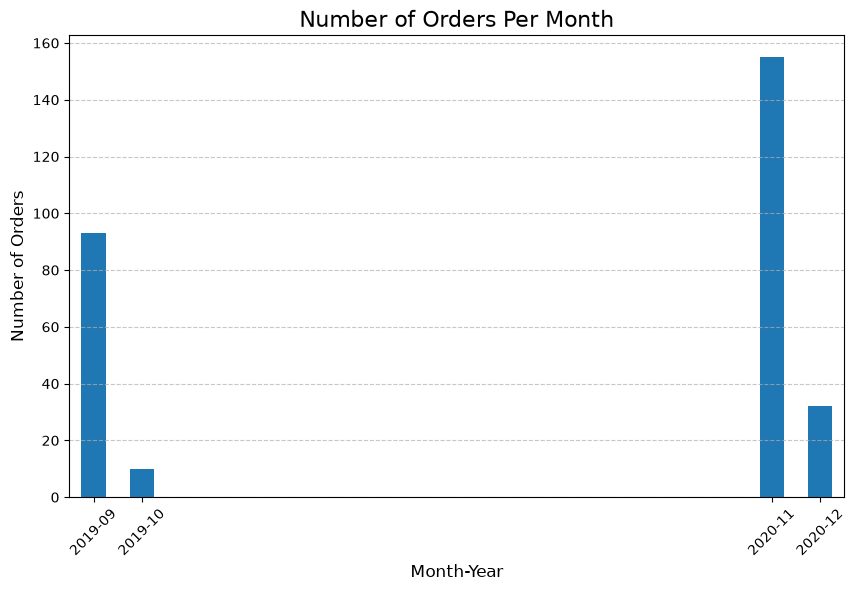

In [513]:
orders_per_month.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Orders Per Month', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 8. Orders ready on Friday experience longer waiting times because trucks leave only on Monday, Wednesday, and Friday. - delivery time by day of the order -> if Monday, but then, focus on weekdays Fruzs

In [514]:
order_process_raw.head()

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,processing_days,within_2_days
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express,4,False
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing,7,False
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing,7,False
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing,6,False
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing,6,False


In [515]:
intern_data_study.head()

,Order ID,Ready to Ship Date,Pickup Date,storagetime,Month-Year
0,CA-2019-116540,2019-09-02,2019-09-03,1 days,2019-09
1,CA-2019-116540,2019-09-02,2019-09-03,1 days,2019-09
2,CA-2019-129847,2019-09-04,2019-09-04,0 days,2019-09
3,CA-2019-129630,2019-09-04,2019-09-04,0 days,2019-09
4,CA-2019-106278,2019-09-05,2019-09-06,1 days,2019-09


In [516]:
intern_data_study.columns = (intern_data_study.columns
                         .str.strip()
                         .str.replace('/', '_', regex=False)                   # turn / into _ first
                         .str.replace('-', '_', regex=False)                   # - → _
                         .str.replace(r'[^a-zA-Z0-9\s_]', '', regex=True)      # then delete anything else unwanted
                         .str.replace(r'\s+', '_', regex=True)
                         .str.lower())
intern_data_study.columns.tolist()

['order_id', 'ready_to_ship_date', 'pickup_date', 'storagetime', 'month_year']

In [517]:
merged_o_i = order_process_raw.merge(intern_data_study, on='order_id', how='outer')

In [518]:
print(len(order_process_raw))
print(len(intern_data_study))
print(len(merged_o_i))

5899
290
6234


In [519]:
merged_o_i.head()

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,processing_days,within_2_days,ready_to_ship_date,pickup_date,storagetime,month_year
0,4407,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,NaT,NaT,NaT,NaT
1,4408,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,NaT,NaT,NaT,NaT
2,4409,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,7,False,NaT,NaT,NaT,NaT
3,1894,CA-2019-100083,2019-11-24,2019-12-04,Standard Processing,10,False,NaT,NaT,NaT,NaT
4,456,CA-2019-100153,2019-12-13,2019-12-18,Standard Processing,5,False,NaT,NaT,NaT,NaT


In [520]:
merged_o_i['days_difference'] = (merged_o_i['pickup_date'] - merged_o_i['on_truck_scan_date']).dt.days

In [521]:
print(merged_o_i[['on_truck_scan_date', 'pickup_date', 'days_difference']].head(10))
print(merged_o_i['days_difference'].isna().sum())

  on_truck_scan_date pickup_date  days_difference
0         2019-11-27         NaT              NaN
1         2019-11-27         NaT              NaN
2         2019-11-27         NaT              NaN
3         2019-12-04         NaT              NaN
4         2019-12-18         NaT              NaN
5         2020-01-08         NaT              NaN
6         2019-09-25  2019-09-25              0.0
7         2019-09-25  2019-09-25              0.0
8         2019-09-25  2019-09-25              0.0
9         2019-09-25  2019-09-25              0.0
5481


In [522]:
# Group 1: dates exist and match exactly (difference is 0)
matching_dates = merged_o_i[merged_o_i['days_difference'] == 0.0]
# Group 2: dates exist but do not match
different_dates = merged_o_i[(merged_o_i['days_difference'].notna()) & (merged_o_i['days_difference'] != 0)]

In [523]:
print(len(matching_dates))
print(len(different_dates))
print(len(merged_o_i))
# since we do not have data where on truck_scan_date and pickup_date is different, 
# but 753 occasions when they are the same, we can use one or the other for our analyis

753
0
6234


In [524]:
merged_o_i['on_truck_pick_up_combined'] = merged_o_i['on_truck_scan_date'].fillna(merged_o_i['pickup_date'])
# in order to have more data for analysis, I created a on_truck_pick_up_combined that takes value from on truck scan date 
# or from pick up date if not available

In [525]:
print(merged_o_i[['on_truck_scan_date', 'pickup_date', 'on_truck_pick_up_combined']].head(20))
print(merged_o_i['on_truck_pick_up_combined'].isna().sum())

   on_truck_scan_date pickup_date on_truck_pick_up_combined
0          2019-11-27         NaT                2019-11-27
1          2019-11-27         NaT                2019-11-27
2          2019-11-27         NaT                2019-11-27
3          2019-12-04         NaT                2019-12-04
4          2019-12-18         NaT                2019-12-18
5          2020-01-08         NaT                2020-01-08
6          2019-09-25  2019-09-25                2019-09-25
7          2019-09-25  2019-09-25                2019-09-25
8          2019-09-25  2019-09-25                2019-09-25
9          2019-09-25  2019-09-25                2019-09-25
10         2019-09-25  2019-09-25                2019-09-25
11         2019-09-25  2019-09-25                2019-09-25
12         2019-09-25  2019-09-25                2019-09-25
13         2019-09-25  2019-09-25                2019-09-25
14         2019-09-25  2019-09-25                2019-09-25
15         2019-09-25  2019-09-25       

In [526]:
# new processing and within_2_days columns
merged_o_i = merged_o_i.drop(columns=['processing_days', 'within_2_days'])
merged_o_i['processing_days'] = (merged_o_i['on_truck_scan_date'] - merged_o_i['order_date']).dt.days
merged_o_i['within_2_days'] = merged_o_i['processing_days'] <= 2
merged_o_i.head()


,row_id,order_id,order_date,on_truck_scan_date,ship_mode,ready_to_ship_date,pickup_date,storagetime,month_year,days_difference,on_truck_pick_up_combined,processing_days,within_2_days
0,4407,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-11-27,7,False
1,4408,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-11-27,7,False
2,4409,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-11-27,7,False
3,1894,CA-2019-100083,2019-11-24,2019-12-04,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-12-04,10,False
4,456,CA-2019-100153,2019-12-13,2019-12-18,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-12-18,5,False


In [527]:
print(merged_o_i['within_2_days'].value_counts(normalize=True) * 100)
# 90% of the orders are not processed within two days

within_2_days
False    89.637472
True     10.362528
Name: proportion, dtype: float64


In [528]:
merged_o_i['processing_days'].describe()
# avg processing day is 6, max is 12

count    6234.000000
mean        6.135868
std         2.487186
min         0.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        12.000000
Name: processing_days, dtype: float64

In [529]:
merged_o_i['processing_days'].mode()
# Most often processing day is 7

0    7
Name: processing_days, dtype: int64

In [530]:
merged_o_i['processing_days'].median()
# Median of processing day is alsoi 7

np.float64(7.0)

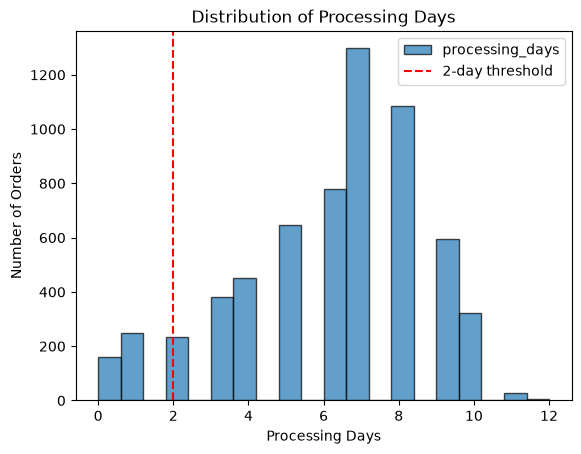

In [531]:
merged_o_i['processing_days'].plot.hist(bins=20, edgecolor='black', alpha=0.7)
plt.axvline(2, color='red', linestyle='--', label='2-day threshold')
plt.xlabel('Processing Days')
plt.ylabel('Number of Orders')
plt.title('Distribution of Processing Days')
plt.legend()
plt.show()

In [532]:
merged_o_i['order_day_of_week'] = merged_o_i['order_date'].dt.day_name()
merged_o_i['ready_to_ship_day_of_week'] = merged_o_i['ready_to_ship_date'].dt.day_name()
merged_o_i['on_truck_pick_up_day_of_week'] = merged_o_i['on_truck_pick_up_combined'].dt.day_name()
merged_o_i.head(10)

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,ready_to_ship_date,pickup_date,storagetime,month_year,days_difference,on_truck_pick_up_combined,processing_days,within_2_days,order_day_of_week,ready_to_ship_day_of_week,on_truck_pick_up_day_of_week
0,4407,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-11-27,7,False,Wednesday,NaN,Wednesday
1,4408,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-11-27,7,False,Wednesday,NaN,Wednesday
2,4409,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-11-27,7,False,Wednesday,NaN,Wednesday
3,1894,CA-2019-100083,2019-11-24,2019-12-04,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-12-04,10,False,Sunday,NaN,Wednesday
4,456,CA-2019-100153,2019-12-13,2019-12-18,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-12-18,5,False,Friday,NaN,Wednesday
5,2822,CA-2019-100202,2019-12-31,2020-01-08,Standard Processing,NaT,NaT,NaT,NaT,NaN,2020-01-08,8,False,Tuesday,NaN,Wednesday
6,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,2019-09-25,5,False,Friday,Tuesday,Wednesday
7,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,2019-09-25,5,False,Friday,Tuesday,Wednesday
8,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,2019-09-25,5,False,Friday,Tuesday,Wednesday
9,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,2019-09-25,5,False,Friday,Tuesday,Wednesday


In [533]:
avg_processing_by_day = merged_o_i.groupby('order_day_of_week')['processing_days'].mean()
print(avg_processing_by_day)

order_day_of_week
Friday       5.473348
Monday       6.384542
Saturday     5.941176
Sunday       7.512605
Thursday     5.648479
Tuesday      6.336127
Wednesday    6.080285
Name: processing_days, dtype: float64


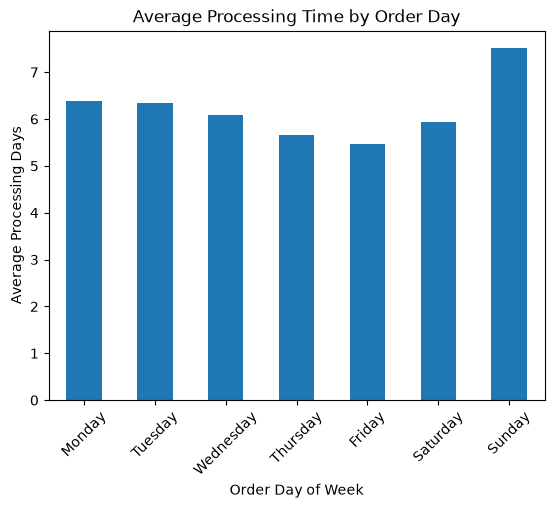

In [534]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

avg_processing_by_day = merged_o_i.groupby('order_day_of_week')['processing_days'].mean()
avg_processing_by_day = avg_processing_by_day.reindex(day_order)

avg_processing_by_day.plot.bar()
plt.xlabel('Order Day of Week')
plt.ylabel('Average Processing Days')
plt.title('Average Processing Time by Order Day')
plt.xticks(rotation=45)
plt.show()
# Friday actually has the lowest processing day, depsite the warehouse being close and no pick up until Monday

# 6. **Some orders** miss the next available truck. -open difference between ready for ship and pick up time, from Internstudy, Lauritz already calulated it


Ready to Ship (2 business days, warehouse closed weekends; weekend orders roll to Monday
Ready for Pickup → Next Truck (trucks run Mon/Wed/Fri only; standard orders ship the first truck day after ready)

| Order Received | Ready to Ship | Expected Truck | Total Wait (Order → Truck) |
|---|---|---|---|
| Monday | Wednesday | Friday | 4 days |
| Tuesday | Thursday | Friday | 3 days |
| Wednesday | Friday | Monday (next week) | 5 days |
| Thursday | Monday (next week) | Wednesday (next week) | 6 days |
| Friday | Tuesday (next week) | Wednesday (next week) | 5 days |
| Saturday / Sunday | Wednesday | Friday | 4 days |

In [446]:
merged_o_i['order_day_of_week'] = merged_o_i['order_date'].dt.day_name()
merged_o_i['ready_to_ship_day_of_week'] = merged_o_i['ready_to_ship_date'].dt.day_name()
merged_o_i['on_truck_pick_up_day_of_week'] = merged_o_i['on_truck_pick_up_combined'].dt.day_name()
merged_o_i.head(10)

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,ready_to_ship_date,pickup_date,storagetime,month_year,days_difference,on_truck_pick_up_combined,processing_days,within_2_days,order_day_of_week,ready_to_ship_day_of_week,on_truck_pick_up_day_of_week
0,4407,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-11-27,7,False,Wednesday,NaN,Wednesday
1,4408,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-11-27,7,False,Wednesday,NaN,Wednesday
2,4409,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-11-27,7,False,Wednesday,NaN,Wednesday
3,1894,CA-2019-100083,2019-11-24,2019-12-04,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-12-04,10,False,Sunday,NaN,Wednesday
4,456,CA-2019-100153,2019-12-13,2019-12-18,Standard Processing,NaT,NaT,NaT,NaT,NaN,2019-12-18,5,False,Friday,NaN,Wednesday
5,2822,CA-2019-100202,2019-12-31,2020-01-08,Standard Processing,NaT,NaT,NaT,NaT,NaN,2020-01-08,8,False,Tuesday,NaN,Wednesday
6,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,2019-09-25,5,False,Friday,Tuesday,Wednesday
7,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,2019-09-25,5,False,Friday,Tuesday,Wednesday
8,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,2019-09-25,5,False,Friday,Tuesday,Wednesday
9,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,2019-09-25,5,False,Friday,Tuesday,Wednesday


In [ ]:
merged_o_i_enr = merged_o_i.copy()
# creating a copy for the analysis

In [ ]:
expected_ready_list = []
expected_truck_list = []
ready_matches_list = []
truck_matches_list = []
overall_matches_list = []

for i in range(len(merged_o_i_enr)):
    order_day = merged_o_i_enr["order_day_of_week"].iloc[i]
    ready_day = merged_o_i_enr["ready_to_ship_day_of_week"].iloc[i]
    truck_day = merged_o_i_enr["on_truck_pick_up_day_of_week"].iloc[i]

    expected_ready, expected_truck, ready_result, truck_result, overall_result = check_match(order_day, ready_day, truck_day)

    expected_ready_list.append(expected_ready)
    expected_truck_list.append(expected_truck)
    ready_matches_list.append(ready_result)
    truck_matches_list.append(truck_result)
    overall_matches_list.append(overall_result)

merged_o_i_enr["ready_to_ship_day_of_week_expected"] = expected_ready_list
merged_o_i_enr["on_truck_pick_up_day_of_week_expected"] = expected_truck_list
merged_o_i_enr["ready_matches"] = ready_matches_list
merged_o_i_enr["truck_matches"] = truck_matches_list
merged_o_i_enr["matches_expected"] = overall_matches_list

print
#it goes through every row, asks check_match() what should have happened vs what did happen, 
# collects those answers into lists, and then saves those lists as five new columns.

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [559]:
merged_o_i_enr.head(10)

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,ready_to_ship_date,pickup_date,storagetime,month_year,days_difference,...,processing_days,within_2_days,order_day_of_week,ready_to_ship_day_of_week,on_truck_pick_up_day_of_week,ready_to_ship_day_of_week_expected,on_truck_pick_up_day_of_week_expected,ready_matches,truck_matches,matches_expected
0,4407,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,...,7,False,Wednesday,NaN,Wednesday,Friday,Monday,None,False,None
1,4408,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,...,7,False,Wednesday,NaN,Wednesday,Friday,Monday,None,False,None
2,4409,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,...,7,False,Wednesday,NaN,Wednesday,Friday,Monday,None,False,None
3,1894,CA-2019-100083,2019-11-24,2019-12-04,Standard Processing,NaT,NaT,NaT,NaT,NaN,...,10,False,Sunday,NaN,Wednesday,Wednesday,Friday,None,False,None
4,456,CA-2019-100153,2019-12-13,2019-12-18,Standard Processing,NaT,NaT,NaT,NaT,NaN,...,5,False,Friday,NaN,Wednesday,Tuesday,Wednesday,None,True,None
5,2822,CA-2019-100202,2019-12-31,2020-01-08,Standard Processing,NaT,NaT,NaT,NaT,NaN,...,8,False,Tuesday,NaN,Wednesday,Thursday,Friday,None,False,None
6,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,...,5,False,Friday,Tuesday,Wednesday,Tuesday,Wednesday,True,True,True
7,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,...,5,False,Friday,Tuesday,Wednesday,Tuesday,Wednesday,True,True,True
8,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,...,5,False,Friday,Tuesday,Wednesday,Tuesday,Wednesday,True,True,True
9,3411,CA-2019-100244,2019-09-20,2019-09-25,Standard Processing,2019-09-24,2019-09-25,1 days,2019-09,0.0,...,5,False,Friday,Tuesday,Wednesday,Tuesday,Wednesday,True,True,True


In [ ]:
ready_known = [r for r in ready_matches_list if r is not None]
truck_known = [r for r in truck_matches_list if r is not None]
overall_known = [r for r in overall_matches_list if r is not None]

print("")
print("Ready-to-Ship matches expected:", round(sum(ready_known) / len(ready_known) * 100, 1), "%  (n =", len(ready_known), ")")
print("Truck pickup matches expected:", round(sum(truck_known) / len(truck_known) * 100, 1), "%  (n =", len(truck_known), ")")
print("Both match expected:", round(sum(overall_known) / len(overall_known) * 100, 1), "%  (n =", len(overall_known), ")")
# to aggregate and normalize the resutlss


Ready-to-Ship matches expected: 14.7 %  (n = 753 )
Truck pickup matches expected: 27.4 %  (n = 6234 )
Both match expected: 11.6 %  (n = 753 )


In [ ]:
problem_list = []

for i in range(len(merged_o_i_enr)):
    ready_result = merged_o_i_enr["ready_matches"].iloc[i]
    truck_result = merged_o_i_enr["truck_matches"].iloc[i]

    if ready_result is None or truck_result is None:
        problem = None  # missing data, can't evaluate
    elif ready_result == True and truck_result == True:
        problem = "no problem — both matched"
    elif ready_result == False and truck_result == True:
        problem = "ready-to-ship was the problem"
    elif ready_result == True and truck_result == False:
        problem = "truck pickup was the problem"
    elif ready_result == False and truck_result == False:
        problem = "both were the problem"

    problem_list.append(problem)

merged_o_i_enr["problem_source"] = problem_list
#for every order, it looks at whether the Ready-to-Ship step matched, 
# whether the Truck pickup step matched, and labels each row with which step (if any) went wrong.

In [569]:
counts = merged_o_i_enr["problem_source"].value_counts()
percentages = merged_o_i_enr["problem_source"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "count": counts,
    "percent": percentages.round(1)
})
summary

,count,percent
problem_source,,
both were the problem,548,72.8
ready-to-ship was the problem,94,12.5
no problem — both matched,87,11.6
truck pickup was the problem,24,3.2


In [ ]:
def expected_days_for_order(order_day):
    if order_day == "Monday":
        return 4
    elif order_day == "Tuesday":
        return 3
    elif order_day == "Wednesday":
        return 5
    elif order_day == "Thursday":
        return 6
    elif order_day == "Friday":
        return 5
    elif order_day == "Saturday":
        return 4
    elif order_day == "Sunday":
        return 4
    else:
        return None
    # prepare analysis to check if too fast or too slow

In [562]:
speed_list = []

for i in range(len(merged_o_i_enr)):
    order_day = merged_o_i_enr["order_day_of_week"].iloc[i]
    actual_days = merged_o_i_enr["processing_days"].iloc[i]

    expected_days = expected_days_for_order(order_day)

    if pd.isna(actual_days) or expected_days is None:
        speed = None
    elif actual_days < expected_days:
        speed = "faster than expected"
    elif actual_days > expected_days:
        speed = "slower than expected"
    else:
        speed = "on time"

    speed_list.append(speed)

merged_o_i_enr["expected_processing_days"] = merged_o_i_enr["order_day_of_week"].apply(expected_days_for_order)
merged_o_i_enr["speed_vs_expected"] = speed_list

In [565]:
merged_o_i_enr.head()

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,ready_to_ship_date,pickup_date,storagetime,month_year,days_difference,...,order_day_of_week,ready_to_ship_day_of_week,on_truck_pick_up_day_of_week,ready_to_ship_day_of_week_expected,on_truck_pick_up_day_of_week_expected,ready_matches,truck_matches,matches_expected,expected_processing_days,speed_vs_expected
0,4407,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,...,Wednesday,NaN,Wednesday,Friday,Monday,None,False,None,5,slower than expected
1,4408,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,...,Wednesday,NaN,Wednesday,Friday,Monday,None,False,None,5,slower than expected
2,4409,CA-2019-100041,2019-11-20,2019-11-27,Standard Processing,NaT,NaT,NaT,NaT,NaN,...,Wednesday,NaN,Wednesday,Friday,Monday,None,False,None,5,slower than expected
3,1894,CA-2019-100083,2019-11-24,2019-12-04,Standard Processing,NaT,NaT,NaT,NaT,NaN,...,Sunday,NaN,Wednesday,Wednesday,Friday,None,False,None,4,slower than expected
4,456,CA-2019-100153,2019-12-13,2019-12-18,Standard Processing,NaT,NaT,NaT,NaT,NaN,...,Friday,NaN,Wednesday,Tuesday,Wednesday,None,True,None,5,on time


In [563]:
merged_o_i_enr["speed_vs_expected"].value_counts()

speed_vs_expected
slower than expected    3626
on time                 1626
faster than expected     982
Name: count, dtype: int64

In [567]:
merged_o_i_enr["speed_vs_expected"].value_counts(normalize=True) * 100

speed_vs_expected
slower than expected    58.164902
on time                 26.082772
faster than expected    15.752326
Name: proportion, dtype: float64

In [577]:
merged_o_i_enr["ship_mode"].value_counts()

ship_mode
Standard Processing    4882
Express                1352
Name: count, dtype: int64

In [ ]:
standard_only = merged_o_i_enr[merged_o_i_enr["ship_mode"] == "Standard Processing"].copy()
# narrowing it down to standard processing

In [572]:
ready_known = standard_only["ready_matches"].dropna().tolist()
truck_known = standard_only["truck_matches"].dropna().tolist()
overall_known = standard_only["matches_expected"].dropna().tolist()

print("Ready-to-Ship matches expected:", round(sum(ready_known) / len(ready_known) * 100, 1), "%  (n =", len(ready_known), ")")
print("Truck pickup matches expected:", round(sum(truck_known) / len(truck_known) * 100, 1), "%  (n =", len(truck_known), ")")
print("Both match expected:", round(sum(overall_known) / len(overall_known) * 100, 1), "%  (n =", len(overall_known), ")")

Ready-to-Ship matches expected: 13.6 %  (n = 602 )
Truck pickup matches expected: 28.1 %  (n = 4882 )
Both match expected: 13.1 %  (n = 602 )


In [573]:
for day in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]:
    subset = standard_only[standard_only["order_day_of_week"] == day]
    truck_results_for_day = subset["truck_matches"].dropna().tolist()

    if len(truck_results_for_day) > 0:
        pct = sum(truck_results_for_day) / len(truck_results_for_day) * 100
        print(day, ":", round(pct, 1), "% matched  (n =", len(truck_results_for_day), ")")
    else:
        print(day, ": no data")

Monday : 16.2 % matched  (n = 820 )
Tuesday : 10.3 % matched  (n = 848 )
Wednesday : 8.8 % matched  (n = 872 )
Thursday : 69.6 % matched  (n = 863 )
Friday : 46.5 % matched  (n = 742 )
Saturday : 16.5 % matched  (n = 254 )
Sunday : 18.0 % matched  (n = 483 )


In [574]:
counts = standard_only["speed_vs_expected"].value_counts()
percentages = standard_only["speed_vs_expected"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": counts, "percent": percentages.round(1)})
summary

,count,percent
speed_vs_expected,,
slower than expected,3544,72.6
on time,1327,27.2
faster than expected,11,0.2


In [575]:
# among all checkable Standard orders
counts = standard_only["problem_source"].value_counts()
percentages = standard_only["problem_source"].value_counts(normalize=True) * 100
summary = pd.DataFrame({"count": counts, "percent": percentages.round(1)})
summary

,count,percent
problem_source,,
both were the problem,466,77.4
no problem — both matched,79,13.1
ready-to-ship was the problem,54,9.0
truck pickup was the problem,3,0.5
